# Responsible AI & Model Interpretation

## Heart Disease Prediction using SHAP Explainability and Bias Analysis

### InternSpark Artificial Intelligence Internship - Task 

**Author:** Yash Kumar

This notebook demonstrates feature importance analysis, SHAP explainability, bias evaluation across gender groups, and mitigation recommendations for a Heart Disease Prediction model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.getcwd()

'C:\\My Code\\InternSpark Artificial Intelligence Internship\\Responsible AI & Model Interpretation'

In [3]:
import os
os.listdir()

['.ipynb_checkpoints', 'Responsible_AI_Model_Interpretation.ipynb']

In [4]:
import os
print(os.getcwd())

C:\My Code\InternSpark Artificial Intelligence Internship\Responsible AI & Model Interpretation


In [5]:
import os

os.chdir(r"C:\My Code\InternSpark Artificial Intelligence Internship\ML Classification Project")

print(os.getcwd())

C:\My Code\InternSpark Artificial Intelligence Internship\ML Classification Project


In [6]:
import os

print(os.listdir(r"C:\My Code\InternSpark Artificial Intelligence Internship\ML Classification Project\Dataset"))

['heart_disease_uci.csv']


In [7]:
df = pd.read_csv(r"C:\My Code\InternSpark Artificial Intelligence Internship\ML Classification Project\Dataset\heart_disease_uci.csv")

In [8]:
df = pd.read_csv(r"C:\My Code\InternSpark Artificial Intelligence Internship\ML Classification Project\Dataset\heart_disease_uci.csv")

In [9]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [11]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [12]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [13]:
df = df.drop(columns=["id", "dataset", "ca", "thal"])

In [14]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0


In [15]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
num           0
dtype: int64

In [16]:
df["trestbps"] = df["trestbps"].fillna(df["trestbps"].mean())
df["chol"] = df["chol"].fillna(df["chol"].mean())
df["thalch"] = df["thalch"].fillna(df["thalch"].mean())
df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].mean())

In [17]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs          90
restecg       2
thalch        0
exang        55
oldpeak       0
slope       309
num           0
dtype: int64

In [18]:
df["fbs"] = df["fbs"].fillna(df["fbs"].mode()[0])
df["restecg"] = df["restecg"].fillna(df["restecg"].mode()[0])
df["exang"] = df["exang"].fillna(df["exang"].mode()[0])
df["slope"] = df["slope"].fillna(df["slope"].mode()[0])

In [19]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

In [20]:
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

In [21]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

In [22]:
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

In [23]:
df["num"].value_counts()

num
1    509
0    411
Name: count, dtype: int64

In [24]:
df = pd.get_dummies(df, drop_first=True)

In [25]:
df.head()

,age,trestbps,chol,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping
0,63,145.0,233.0,150.0,2.3,0,True,False,False,True,True,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,1,True,False,False,False,False,False,False,True,True,False
2,67,120.0,229.0,129.0,2.6,1,True,False,False,False,False,False,False,True,True,False
3,37,130.0,250.0,187.0,3.5,0,True,False,True,False,False,True,False,False,False,False
4,41,130.0,204.0,172.0,1.4,0,False,True,False,False,False,False,False,False,False,True


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   trestbps                  920 non-null    float64
 2   chol                      920 non-null    float64
 3   thalch                    920 non-null    float64
 4   oldpeak                   920 non-null    float64
 5   num                       920 non-null    int64  
 6   sex_Male                  920 non-null    bool   
 7   cp_atypical angina        920 non-null    bool   
 8   cp_non-anginal            920 non-null    bool   
 9   cp_typical angina         920 non-null    bool   
 10  fbs_True                  920 non-null    bool   
 11  restecg_normal            920 non-null    bool   
 12  restecg_st-t abnormality  920 non-null    bool   
 13  exang_True                920 non-null    bool   
 14  slope_flat           

In [27]:
X = df.drop("num", axis=1)

y = df["num"]

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (736, 15)
Testing Features  : (184, 15)
Training Labels   : (736,)
Testing Labels    : (184,)


In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
model = LogisticRegression(max_iter=1000)

In [33]:
model.fit(X_train, y_train)

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [34]:
predictions = model.predict(X_test)

In [35]:
print(predictions[:10])

[0 0 1 1 0 0 0 1 1 0]


In [36]:
X = df.drop("num", axis=1)
y = df["num"]

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
model = LogisticRegression(max_iter=1000)

In [41]:
model.fit(X_train, y_train)

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [42]:
predictions = model.predict(X_test)

In [43]:
print(predictions[:10])

[0 0 1 1 0 0 0 1 1 0]


In [44]:
from sklearn.preprocessing import StandardScaler

In [45]:
scaler = StandardScaler()

In [46]:
X_train_scaled = scaler.fit_transform(X_train)

In [47]:
X_test_scaled = scaler.transform(X_test)

In [48]:
model = LogisticRegression(max_iter=5000)

In [49]:
model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [50]:
predictions = model.predict(X_test_scaled)

In [51]:
print(predictions[:10])

[0 0 1 1 0 0 0 1 1 0]


In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
scaler = StandardScaler()

In [54]:
X_train_scaled = scaler.fit_transform(X_train)

In [55]:
X_test_scaled = scaler.transform(X_test)

In [56]:
model = LogisticRegression(max_iter=5000)

In [57]:
model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [58]:
predictions = model.predict(X_test_scaled)

In [59]:
print(predictions[:10])

[0 0 1 1 0 0 0 1 1 0]


In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [61]:
print("Accuracy :", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall   :", recall_score(y_test, predictions))
print("F1 Score :", f1_score(y_test, predictions))
print("ROC-AUC  :", roc_auc_score(y_test, predictions))

Accuracy : 0.7934782608695652
Precision: 0.8317757009345794
Recall   : 0.8165137614678899
F1 Score : 0.8240740740740741
ROC-AUC  : 0.788256880733945


In [62]:
print(confusion_matrix(y_test, predictions))

[[57 18]
 [20 89]]


In [63]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.74      0.76      0.75        75
           1       0.83      0.82      0.82       109

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184



In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [66]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [67]:
rf_predictions = rf_model.predict(X_test)

In [68]:
print("Accuracy :", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall   :", recall_score(y_test, rf_predictions))
print("F1 Score :", f1_score(y_test, rf_predictions))
print("ROC-AUC  :", roc_auc_score(y_test, rf_predictions))

Accuracy : 0.842391304347826
Precision: 0.8846153846153846
Recall   : 0.8440366972477065
F1 Score : 0.863849765258216
ROC-AUC  : 0.8420183486238532


In [69]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81        75
           1       0.88      0.84      0.86       109

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.85      0.84      0.84       184



In [70]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.73913043 0.70652174 0.79891304 0.83152174 0.63043478]
Average Accuracy: 0.741304347826087


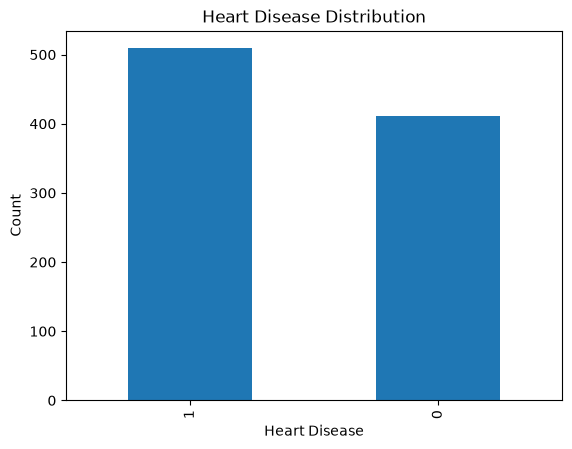

In [71]:
import matplotlib.pyplot as plt

df["num"].value_counts().plot(kind="bar")
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

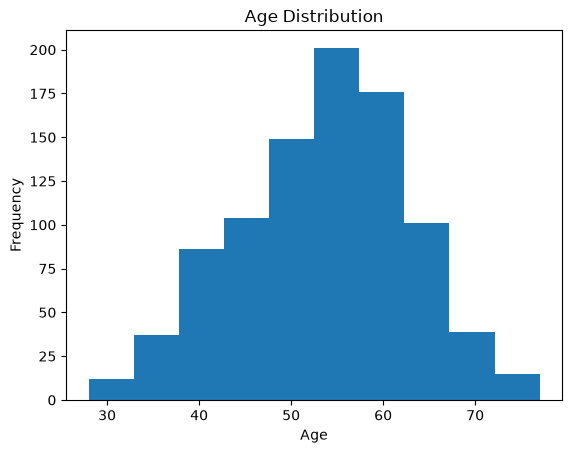

In [72]:
plt.hist(df["age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

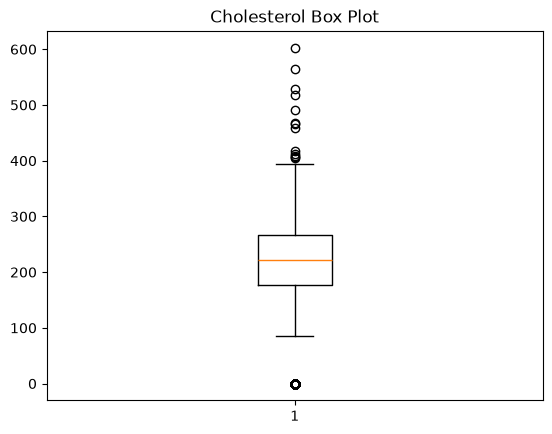

In [73]:
plt.boxplot(df["chol"])
plt.title("Cholesterol Box Plot")
plt.show()

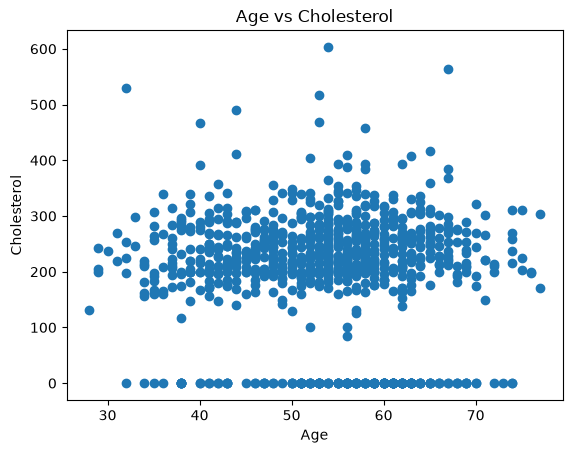

In [74]:
plt.scatter(df["age"], df["chol"])
plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.show()

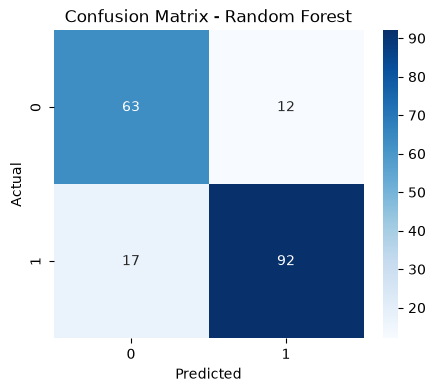

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [76]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                     Feature  Importance
2                       chol    0.153518
3                     thalch    0.149925
4                    oldpeak    0.125123
0                        age    0.118381
1                   trestbps    0.097251
12                exang_True    0.092100
6         cp_atypical angina    0.070916
5                   sex_Male    0.056849
7             cp_non-anginal    0.036171
10            restecg_normal    0.020069
14           slope_upsloping    0.017437
9                   fbs_True    0.017375
8          cp_typical angina    0.015250
11  restecg_st-t abnormality    0.014835
13                slope_flat    0.014800


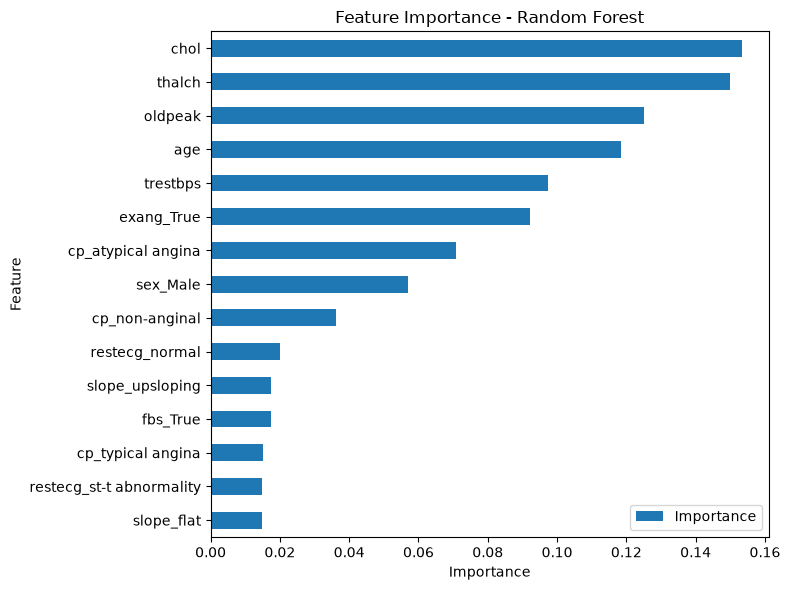

In [77]:
import matplotlib.pyplot as plt

importance.sort_values(by="Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [78]:
import matplotlib.pyplot as plt

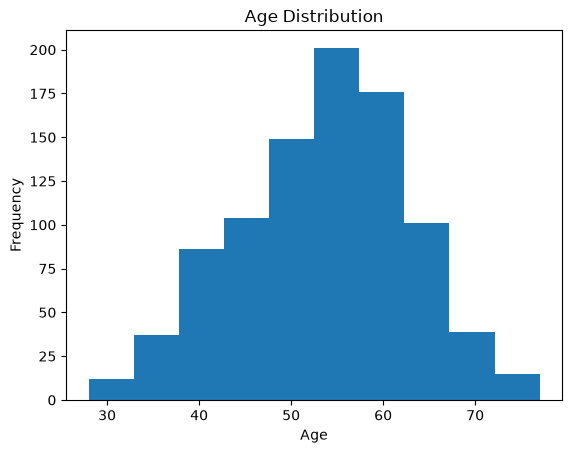

In [79]:
plt.hist(df["age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig("Images/age_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

In [80]:
plt.savefig("Images/bar_chart.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [81]:
plt.savefig("Images/boxplot.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

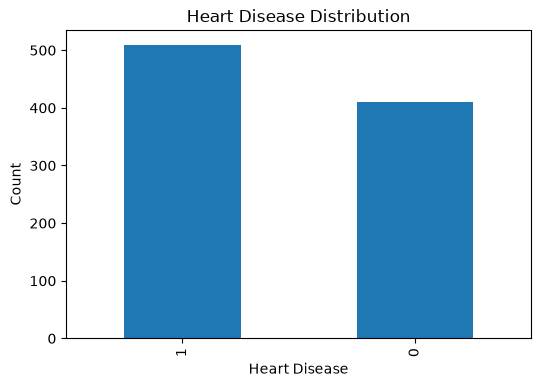

In [82]:
plt.figure(figsize=(6,4))
df["num"].value_counts().plot(kind="bar")
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.savefig("Images/heart_disease_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

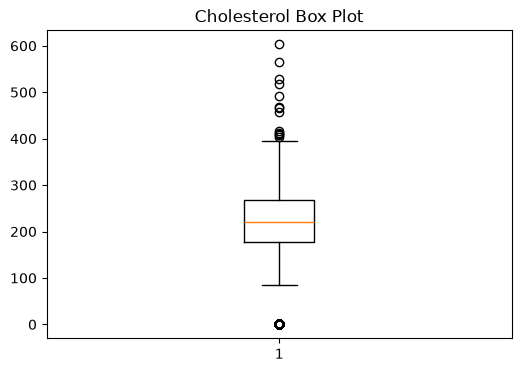

In [83]:
plt.figure(figsize=(6,4))
plt.boxplot(df["chol"])
plt.title("Cholesterol Box Plot")
plt.savefig("Images/cholesterol_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

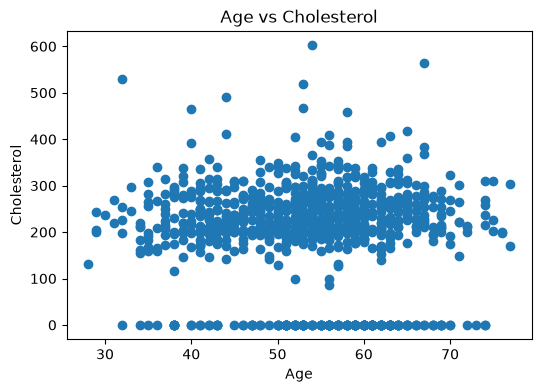

In [84]:
plt.figure(figsize=(6,4))
plt.scatter(df["age"], df["chol"])
plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.savefig("Images/age_vs_cholesterol.png", dpi=300, bbox_inches="tight")
plt.show()

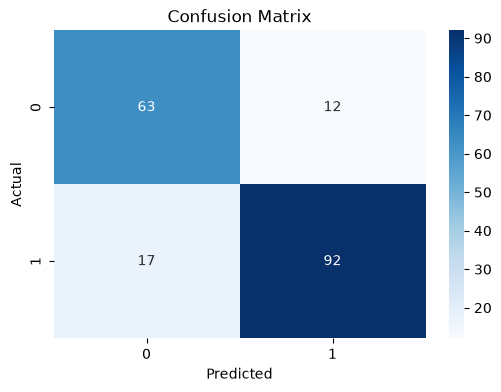

In [85]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

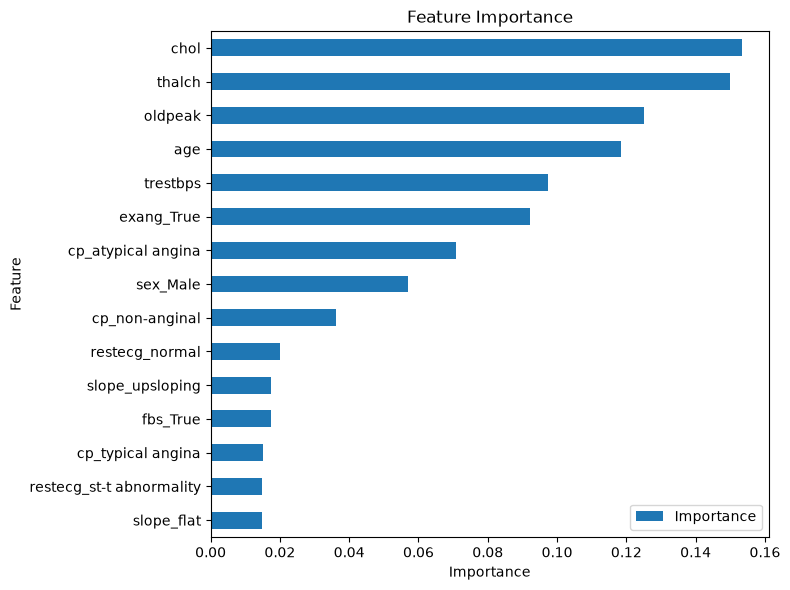

In [86]:
importance.sort_values(by="Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("Images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [87]:
import os
print(os.getcwd())

C:\My Code\InternSpark Artificial Intelligence Internship\ML Classification Project


In [88]:
import pandas as pd

In [89]:
df = pd.read_csv("Dataset/heart_disease_uci.csv")

In [90]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [91]:
import joblib

joblib.dump(rf_model, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [92]:
print(df.shape)

(920, 16)


In [93]:
print(X.shape)

(920, 15)


In [94]:
print(y.shape)

(920,)


In [95]:
print(type(rf_model))
print(X_test.shape)
print(y_test.shape)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
(184, 15)
(184,)


                     Feature  Importance
2                       chol    0.153518
3                     thalch    0.149925
4                    oldpeak    0.125123
0                        age    0.118381
1                   trestbps    0.097251
12                exang_True    0.092100
6         cp_atypical angina    0.070916
5                   sex_Male    0.056849
7             cp_non-anginal    0.036171
10            restecg_normal    0.020069
14           slope_upsloping    0.017437
9                   fbs_True    0.017375
8          cp_typical angina    0.015250
11  restecg_st-t abnormality    0.014835
13                slope_flat    0.014800


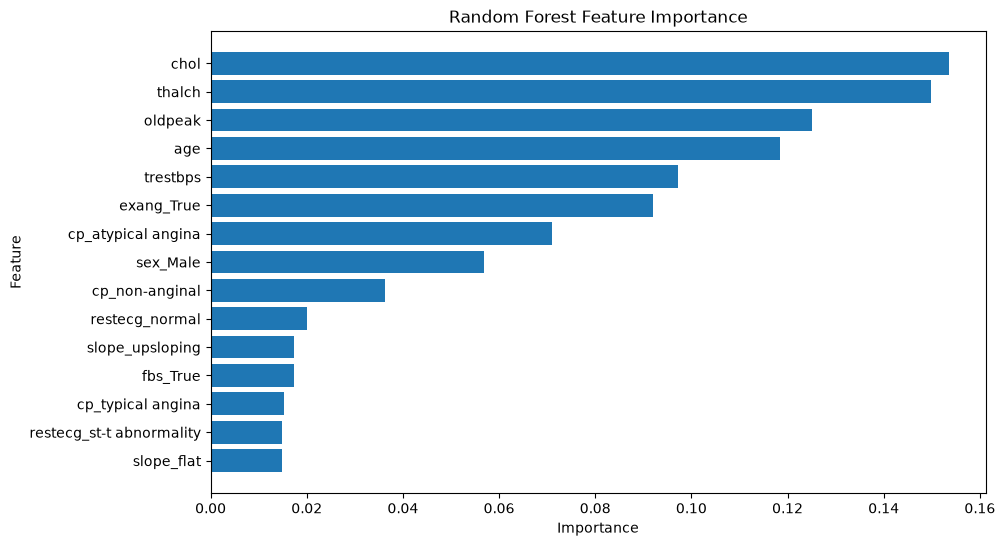

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [97]:
import shap

# Create SHAP Explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


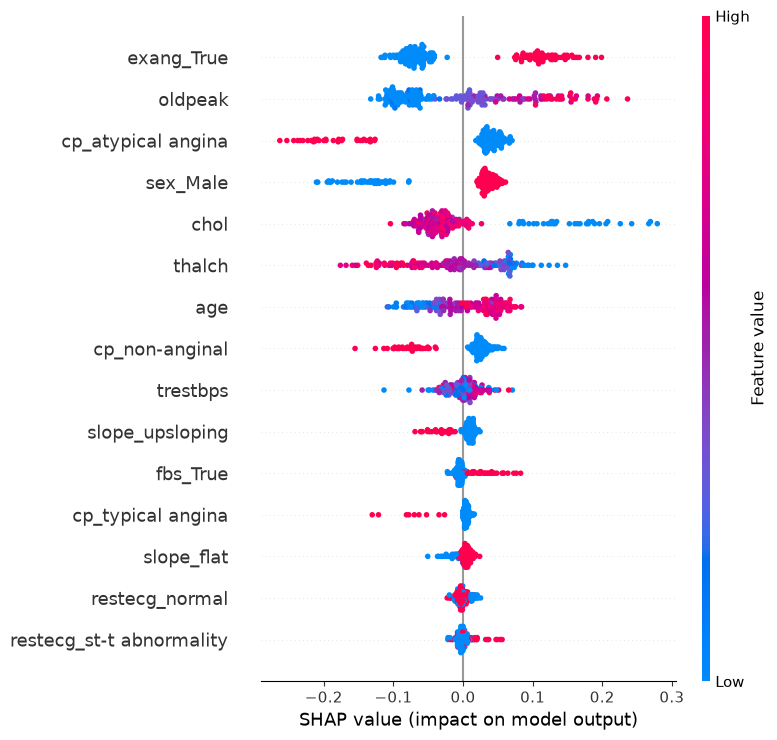

In [98]:
# SHAP Summary Plot (Class 1)
shap.summary_plot(shap_values[:, :, 1], X_test)

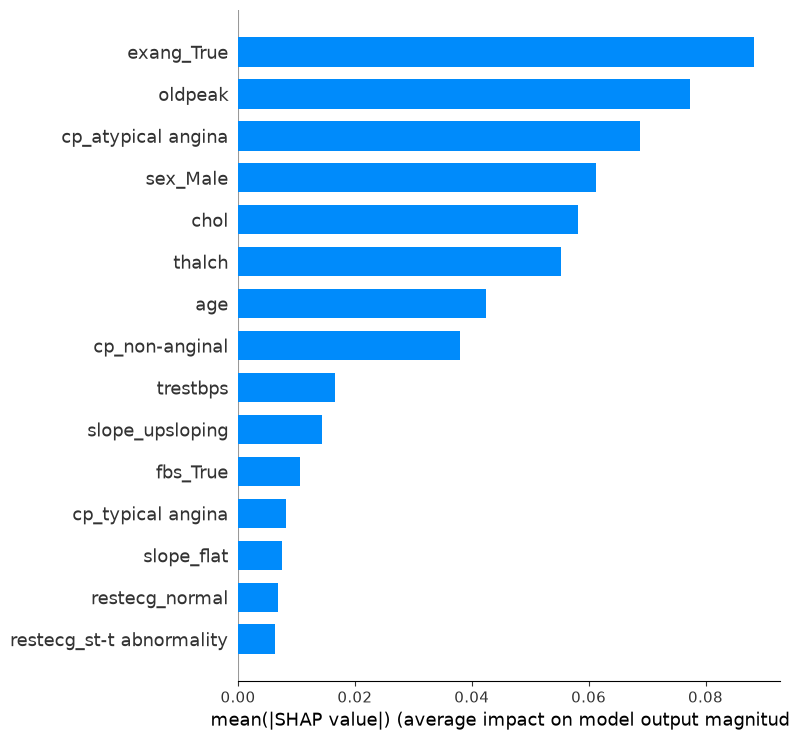

In [99]:
# SHAP Bar Plot (Class 1)
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

In [100]:
import shap

print(shap.__version__)

0.52.0


In [101]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [102]:
print(shap_values.shape)

(184, 15, 2)


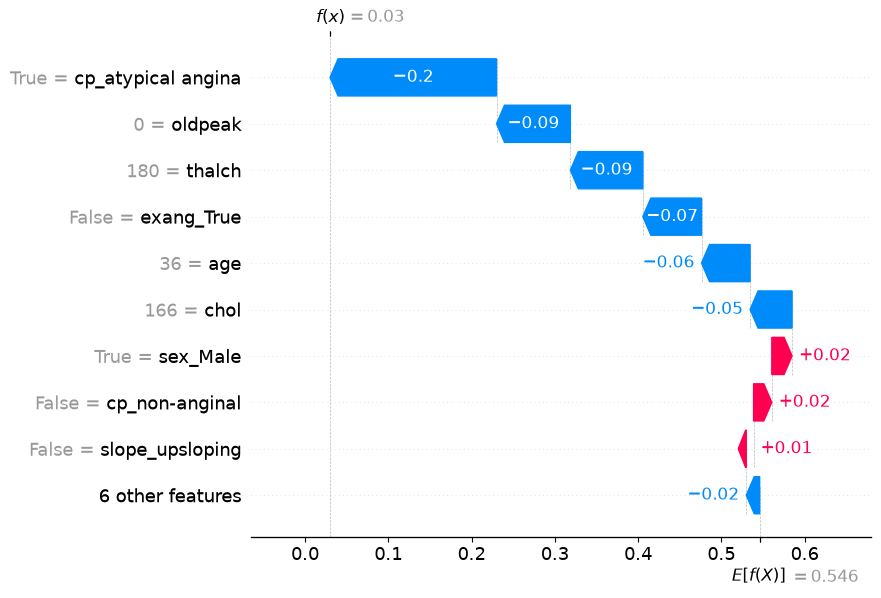

In [103]:
# Local Explanation for the first test sample
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [104]:
from sklearn.metrics import accuracy_score

# Predictions
y_pred = rf_model.predict(X_test)

# Separate Male and Female samples
male_mask = X_test["sex_Male"] == True
female_mask = X_test["sex_Male"] == False

# Accuracy for each group
male_accuracy = accuracy_score(
    y_test[male_mask],
    y_pred[male_mask]
)

female_accuracy = accuracy_score(
    y_test[female_mask],
    y_pred[female_mask]
)

print("Male Accuracy :", round(male_accuracy,4))
print("Female Accuracy :", round(female_accuracy,4))

Male Accuracy : 0.85
Female Accuracy : 0.8182


# Bias Analysis

The model's performance was evaluated separately for male and female groups using the test dataset.

### Results

- **Male Accuracy:** 85.00%
- **Female Accuracy:** 81.82%

The difference in accuracy between the two groups is approximately **3.18%**. Based on this evaluation, there is no strong evidence of significant gender bias in the model's performance on the available test dataset.

Although the difference is relatively small, fairness should continue to be monitored using additional fairness metrics and larger, more diverse datasets.

# Mitigation Recommendations

To promote responsible and fair AI deployment, the following recommendations are proposed:

- Collect balanced datasets representing different demographic groups.
- Monitor fairness metrics regularly during model evaluation.
- Evaluate model performance separately for sensitive groups.
- Retrain the model if significant bias is detected.
- Continue using explainability techniques such as SHAP to improve transparency and trust in model predictions.

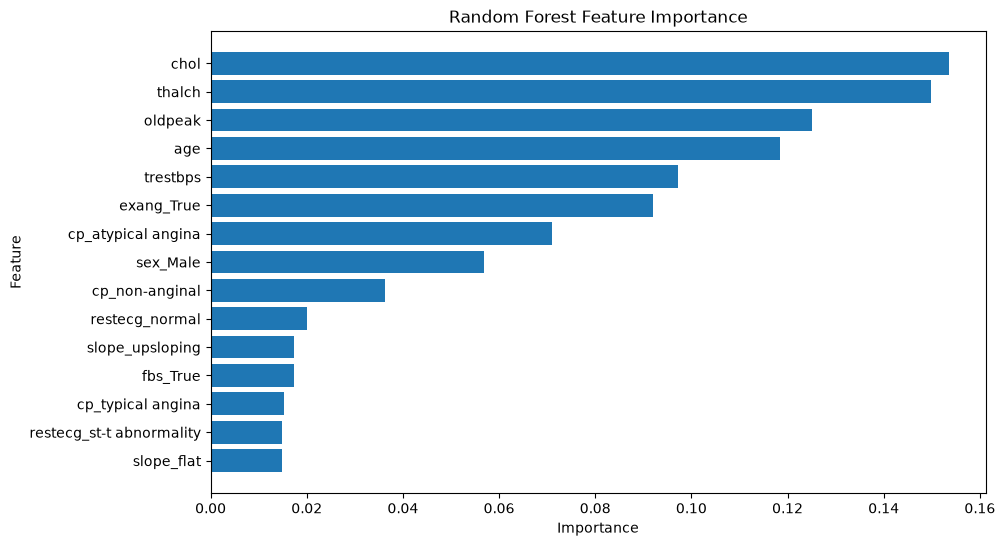

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

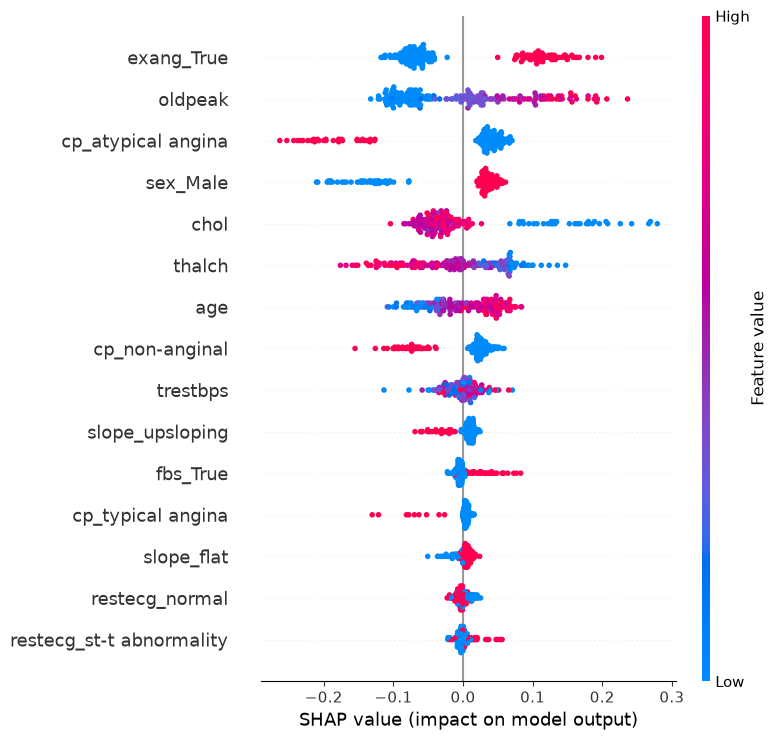

In [106]:
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)

plt.savefig("images/shap_summary.png", dpi=300, bbox_inches="tight")

plt.show()

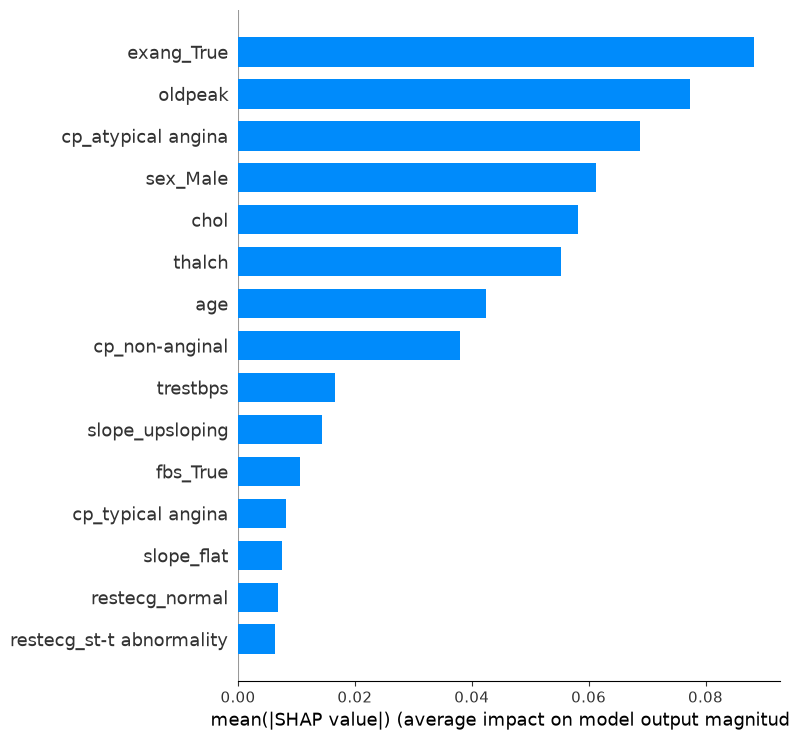

In [107]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig("images/shap_bar.png", dpi=300, bbox_inches="tight")

plt.show()

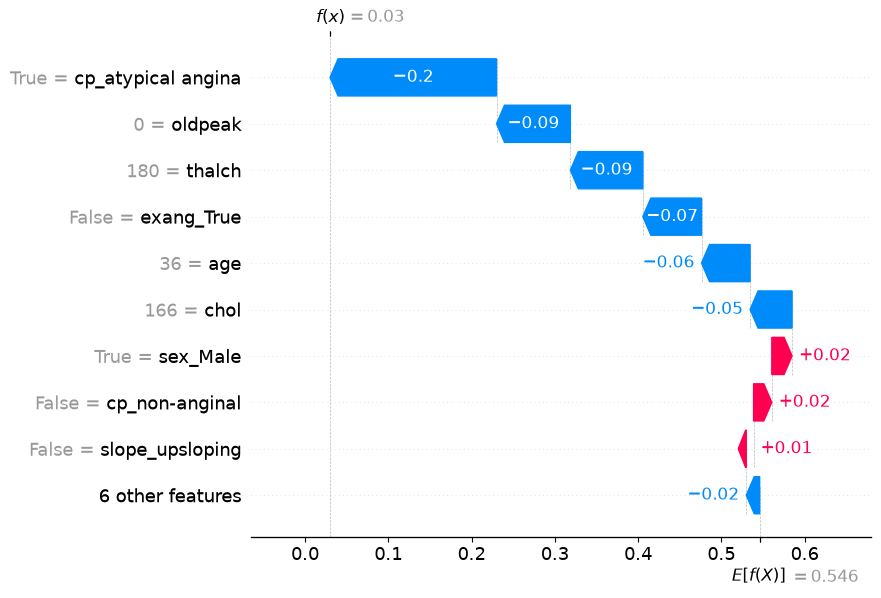

In [108]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    ),
    show=False
)

plt.savefig("images/shap_waterfall.png", dpi=300, bbox_inches="tight")

plt.show()

In [109]:
plt.savefig("Images/feature_importance.png", dpi=300, bbox_inches="tight")

In [110]:
plt.savefig("Images/shap_summary.png", dpi=300, bbox_inches="tight")

In [111]:
plt.savefig("Images/shap_bar.png", dpi=300, bbox_inches="tight")

In [112]:
plt.savefig("Images/shap_waterfall.png", dpi=300, bbox_inches="tight")

In [113]:
import os

print(os.getcwd())

C:\My Code\InternSpark Artificial Intelligence Internship\ML Classification Project


In [114]:
import os

os.chdir(r"C:\My Code\InternSpark Artificial Intelligence Internship\Responsible AI & Model Interpretation")

print(os.getcwd())

C:\My Code\InternSpark Artificial Intelligence Internship\Responsible AI & Model Interpretation


In [116]:
plt.savefig("Images/feature_importance.png", dpi=300, bbox_inches="tight")

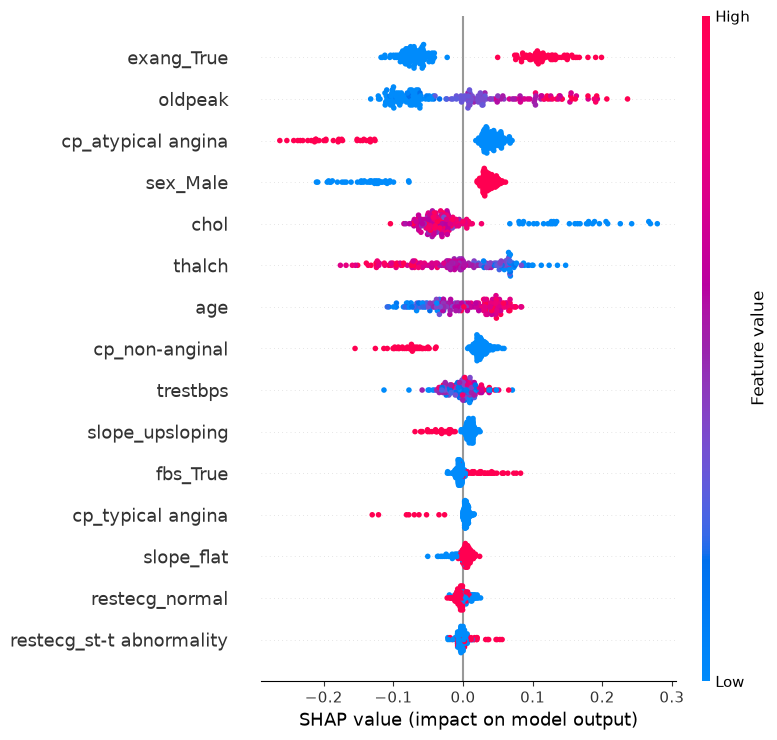

In [117]:
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.savefig("Images/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

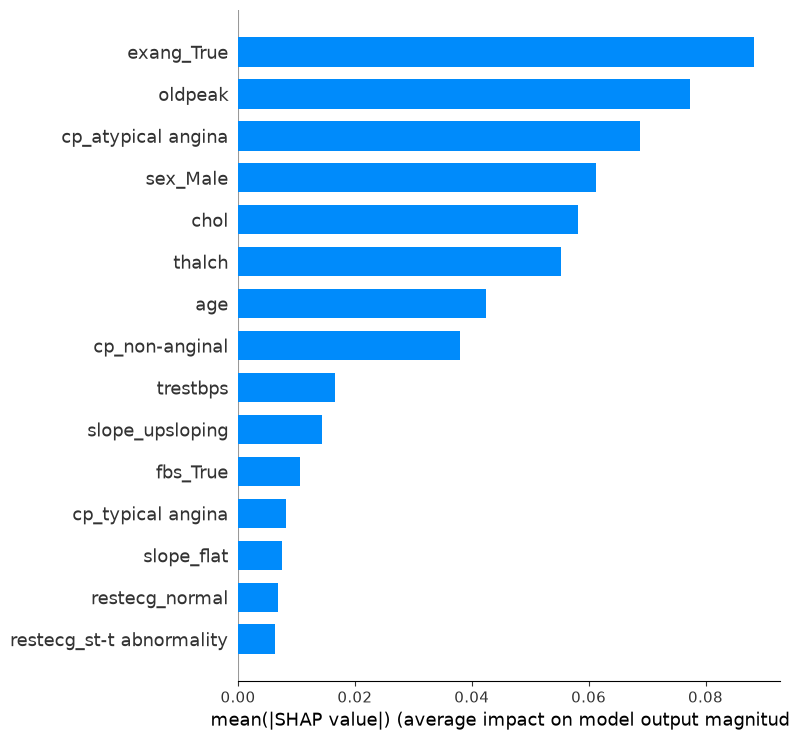

In [118]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", show=False)
plt.savefig("Images/shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

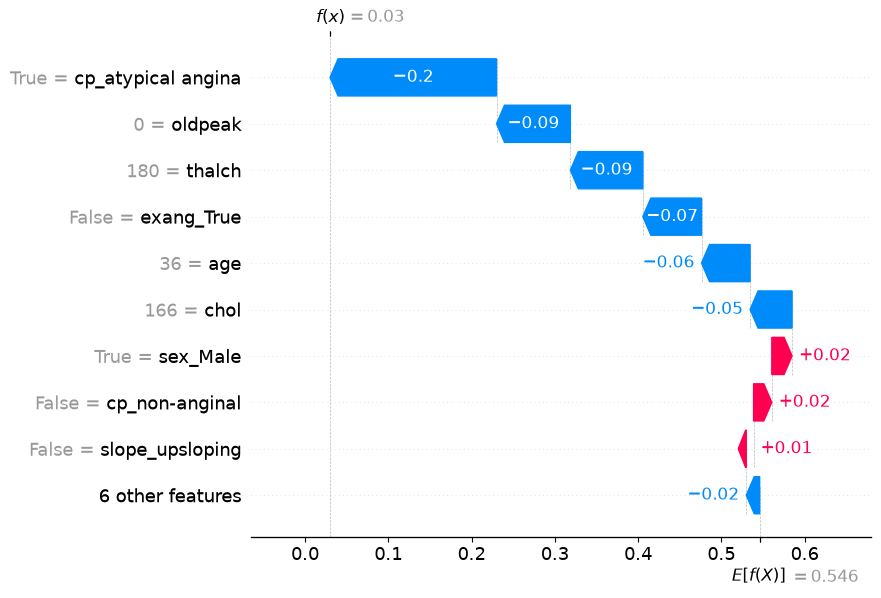

In [119]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    ),
    show=False
)

plt.savefig("Images/shap_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()